In [6]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq
import ctypes
from scipy.signal.windows import hann

<Figure size 640x480 with 0 Axes>

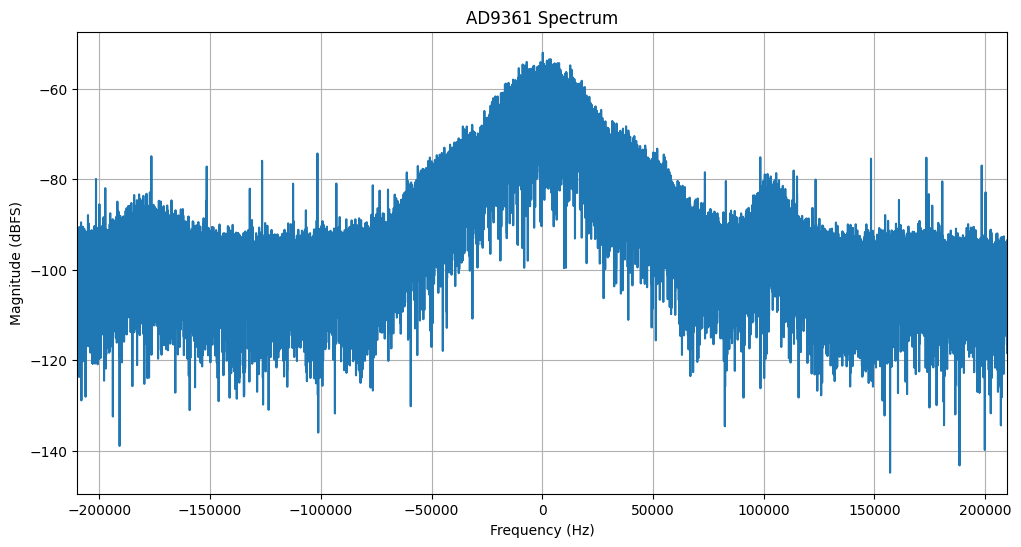

In [17]:
fs = 960e3


# import ad9361_iq.csv
data = np.loadtxt('ad9361_iq.csv', delimiter=',')

data_i = data[:, 0] 
data_q = data[:, 1] 

data_complex = data_i + 1j * data_q
data_complex_ = data_complex * hann(len(data_complex))  # Apply Hann window to reduce spectral leakage
# plot spectrum
plt.figure()

N = len(data_complex)
X = fft(data_complex_)
#normalize X
X = X / N
# convert to FS
X = np.abs(X) / 2**11
X = 20 * np.log10(X)  # Convert to dBFS

X_shifted = fftshift(X)
freqs = fftshift(fftfreq(N, 1/fs))  # assuming sample rate of fs MHz

# plot in range of -210 kHz to 210 kHz
plt.figure(figsize=(12, 6))

plt.plot(freqs[(freqs >= -210e3) & (freqs <= 210e3)], X_shifted[(freqs >= -210e3) & (freqs <= 210e3)])
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dBFS)')
plt.title('AD9361 Spectrum')
plt.xlim(-210e3, 210e3)
plt.grid()

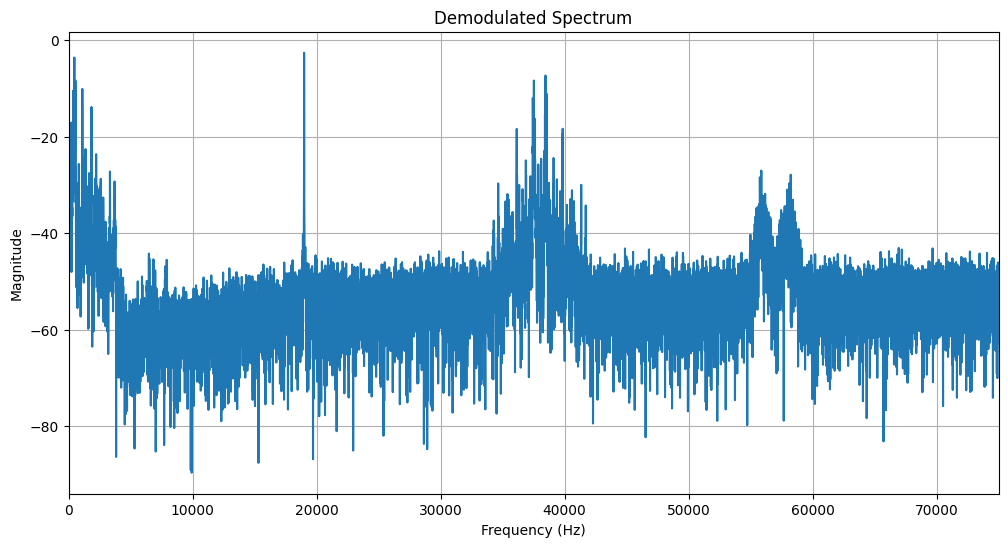

In [4]:
demodualted = np.diff(np.unwrap(np.angle(data_complex)))

# plot spectrum of demodulated signal
plt.figure(figsize=(12, 6))
N = len(demodualted)
X = fft(demodualted)
X = X / N
X = np.abs(X) ** 2 / 1  # Power in watts (assuming 50 ohm load)
X = 10 * np.log10(X * 1e3)  # Convert to dBm
X_shifted = fftshift(X)
freqs = fftshift(fftfreq(N, 1/fs))  # assuming sample rate of fs MHz
# plot positive frequencies only
X_shifted = X_shifted[(freqs >= 0) & (freqs <= 75e3)]
freqs = freqs[(freqs >= 0) & (freqs <= 75e3)]
plt.plot(freqs, X_shifted)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Demodulated Spectrum')
plt.xlim(0, 75e3)
plt.grid()

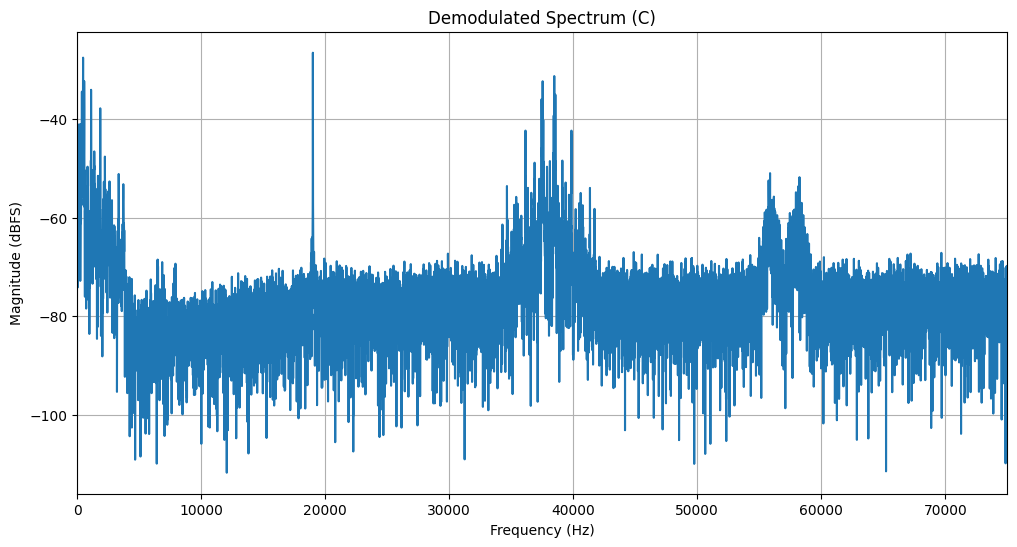

In [8]:
data_i_int = ((data[:, 0] / 2**12) * 2**29).astype(np.int64)
data_q_int = ((data[:, 1] / 2**12) * 2**29).astype(np.int64)

atan2_lib = ctypes.CDLL('./atan2.so')
atan2_lib.atan2.argtypes = [ctypes.c_int64, ctypes.c_int64, ctypes.c_int64]
atan2_lib.atan2.restype = ctypes.POINTER(ctypes.c_int64)

unwrap_diff_lib = ctypes.CDLL('./unwrap_diff.so')
unwrap_diff_lib.unwrap_diff.argtypes = [ctypes.c_int64, ctypes.c_int64]
unwrap_diff_lib.unwrap_diff.restype = ctypes.POINTER(ctypes.c_int64)

angle = np.zeros(len(data_i_int)-1, dtype=np.int64)
angle_unwrap = np.zeros(len(data_i_int)-1)

for i in range(len(data_i_int)-1):
    flg = False
    en = 1
    while not flg:
        angle_ptr = atan2_lib.atan2(en, data_q_int[i], data_i_int[i])
        unwrapped_ptr = unwrap_diff_lib.unwrap_diff(angle_ptr[0], angle_ptr[1])
        unwrapped_ptr = unwrap_diff_lib.unwrap_diff(0, angle_ptr[1])
        en = 0
        flg = True if angle_ptr[0] != 0 else False
    angle[i] = angle_ptr[1]
    angle_unwrap[i] = unwrapped_ptr[1]

angle = angle / (2**29)
angle_unwrap = angle_unwrap / (2**29)

angle_unwrap_ = angle_unwrap * hann(len(angle_unwrap))  # Apply Hann window to reduce spectral leakage
# plot spectrum of demodulated signal
plt.figure(figsize=(12, 6))
N = len(angle_unwrap)
X = fft(angle_unwrap)
X = X / N
full_scale = 0.5
X = 20 * np.log10(np.abs(X) / full_scale)  # Convert to dBFS
X_shifted = fftshift(X)
freqs = fftshift(fftfreq(N, 1/fs))  # assuming sample rate of fs MHz
# plot positive frequencies only
X_shifted = X_shifted[(freqs >= 0) & (freqs <= 75e3)]
freqs = freqs[(freqs >= 0) & (freqs <= 75e3)]
plt.plot(freqs, X_shifted)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dBFS)')
plt.title('Demodulated Spectrum (C)')
plt.xlim(0, 75e3)
plt.grid()

In [9]:
print(len(angle_unwrap))

131071
